In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


True
NVIDIA GeForce RTX 5080
12.8
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
vi_features = ['ndvi_noir_rgb_method', 'gndvi_noir_rgb_method', 'rdvi_noir_rgb_method', 'savi_noir_rgb_method', 'sr_noir_rgb_method','evi_noir_rgb_method', 'cigreen_noir_rgb_method' , 'gli', 'vari']
# weather_features = ['Solar', 'Precipitation', 'AirTemp', 'Vapor_Pressure', 'AtmPressure', 'RelHumidity']
weather_features = []
canopy_temp_features = ['lepton_mean_temp', 'lepton_min_temp', 'lepton_max_temp']
features = vi_features + canopy_temp_features + weather_features
output_variable = 'GYLD_kg_m3'


Text(0.5, 1.0, 'Train vs Test Yield Distribution')

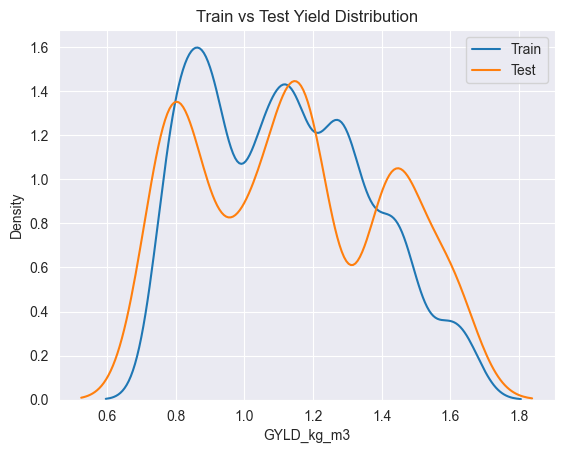

In [5]:
# Loading saved training test
train_df = pd.read_excel("data/stratified_train_test_datasets_v3.xlsx", sheet_name='Train')
test_df = pd.read_excel("data/stratified_train_test_datasets_v3.xlsx", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [7]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


train_df_scaled Rows with at least one NaN: 1167
test_df_scaled Rows with at least one NaN: 364


In [ ]:
# print(X_test_scaled.shape)

In [8]:


def train_data(model, model_train_loader, num_epochs, learning_rate, weight_decay, hyper_param_criterion_method, file_save_name, early_stopping = False):
    best_train_loss  = float('inf')
    patience = 20
    counter = 0

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    if hyper_param_criterion_method == "MSE":
        criterion = nn.MSELoss()
    else:
        criterion = nn.SmoothL1Loss(beta=1)

    total_loss = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in model_train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            # Gradient clipping (prevents exploding gradients)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            train_loss += loss.item() * X_batch.size(0)

        avg_loss = train_loss / len(model_train_loader.dataset)
        total_loss.append(avg_loss)

        print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.5f}")

        if train_loss < best_train_loss:
            best_train_loss = train_loss
            if file_save_name != "":
                torch.save(model.state_dict(), file_save_name)
            counter = 0
        elif early_stopping:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break
    return total_loss


In [9]:
from sklearn.metrics import  mean_squared_error

def evaluate_model(model, val_loader, output_variable_scaler, doInverseTransformScale = False, plot_pred_vs_true = False):

    model.eval()  # set model to evaluation mode
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_hat = model(X_batch)

            y_true.append(y_batch.cpu())
            y_pred.append(y_hat.cpu())

    y_true = torch.cat(y_true).numpy()
    y_pred = torch.cat(y_pred).numpy()

    if doInverseTransformScale:
        y_true = output_variable_scaler.inverse_transform(y_true)
        y_pred = output_variable_scaler.inverse_transform(y_pred)

    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)

    if plot_pred_vs_true:
        plt.figure(figsize=(8,6))
        plt.scatter(y_true, y_pred, alpha=0.7)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
        plt.xlabel("Actual Yield")
        plt.ylabel("Predicted Yield")
        plt.title("LSTM Predictions vs Actual")
        plt.show()

    return r2, mse

In [10]:
window_size = 30
pad_value = -99

K-fold cross validation

In [ ]:
# from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
plot_ids = train_df['plot_id'].unique()
yield_per_plot = train_df.groupby('plot_id')[output_variable].first().values

y_bins = pd.qcut(yield_per_plot, q=5, labels=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [ ]:
from helper import make_progressive_windows
from model_definitions import GRUModel
from vi_dataset import VIDataset

def k_fold_cross_validation(batch_size, k_fold_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    r2_scores = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(plot_ids, y_bins)):
        print(f"Fold {fold+1}")

        train_plots = plot_ids[train_idx]
        val_plots   = plot_ids[val_idx]

        train_df_fold = train_df[train_df['plot_id'].isin(train_plots)]
        val_df_fold   = train_df[train_df['plot_id'].isin(val_plots)]

        # Scaling
        scaler_X_fold = StandardScaler()
        scaler_y_fold = RobustScaler()

        scaler_X_fold.fit(train_df_fold[features])
        scaler_y_fold.fit(train_df_fold[[output_variable]])

        train_df_fold_scaled = train_df_fold.copy()
        val_df_fold_scaled  = val_df_fold.copy()

        train_df_fold_scaled[features] = scaler_X_fold.transform(train_df_fold[features])
        train_df_fold_scaled[output_variable] = scaler_y_fold.transform(train_df_fold[[output_variable]])

        val_df_fold_scaled[features] = scaler_X_fold.transform(val_df_fold[features])
        val_df_fold_scaled[output_variable] = scaler_y_fold.transform(val_df_fold[[output_variable]])

        X_train_fold, y_train_fold = make_progressive_windows(
            dataframe=train_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        X_val_fold, y_val_fold = make_progressive_windows(
            dataframe=val_df_fold_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

        train_dataset_fold = VIDataset(X_train_fold, y_train_fold)
        val_dataset_fold = VIDataset(X_val_fold, y_val_fold)

        train_loader_fold  = DataLoader(train_dataset_fold, batch_size=batch_size, shuffle=True)
        val_loader_fold    = DataLoader(val_dataset_fold, batch_size=batch_size, shuffle=False)

        model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                         output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

        train_data(
            model = model,
            model_train_loader= train_loader_fold,
            num_epochs = k_fold_epochs,
            learning_rate = learning_rate,
            weight_decay = weight_decay,
            hyper_param_criterion_method = hyper_param_criterion_method,
            file_save_name=""
        )

        r2, mse = evaluate_model(
            model = model,
            val_loader = val_loader_fold,
            output_variable_scaler=scaler_y_fold)

        r2_scores.append(r2)
        print(f"Fold {fold+1} R²: {r2:.4f}")

    mean_r2 = np.mean(r2_scores)
    print(f"\n✅ Mean R² across folds: {mean_r2:.4f}")
    return mean_r2

In [11]:
import optuna
from sklearn.metrics import r2_score
from torch.utils.data import DataLoader

search_space = {
    "hidden_size": [8, 16, 32 , 64],
    "num_layers": [1, 2, 3],
    "dropout": [0.0, 0.1, 0.2, 0.3, 0.4, 0.5],
    "lr":  [0.00001, 0.0001, 0.001, 0.01],
    "batch_size": [8, 16, 32, 64],
}

tuning_epochs = 500

def objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = k_fold_cross_validation(
        batch_size= batch_size,
        k_fold_epochs=tuning_epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2


C:\Users\lochana.marasingha\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# sampler = optuna.samplers.GridSampler(search_space)
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)


In [12]:


cols_to_pad = canopy_temp_features + weather_features
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [16]:
from helper import make_progressive_windows
from vi_dataset import VIDataset




In [17]:
from model_definitions import GRUModel

def validation_with_test(trial_id, batch_size, num_epochs, hidden_size, num_layers, dropout, bidirectional, learning_rate, weight_decay, hyper_param_criterion_method):

    X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

    X_test_scaled, y_test_scaled = make_progressive_windows(
        dataframe=test_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)


    train_dataset = VIDataset(X_train_scaled, y_train_scaled)
    test_dataset = VIDataset(X_test_scaled, y_test_scaled)

    train_loader_tuning  = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader_tuning    = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(input_size = len(features), hidden_size = hidden_size, num_layers = num_layers,
                     output_size= 1, dropout=dropout, bidirectional = bidirectional).to(device)

    train_data(
        model = model,
        model_train_loader= train_loader_tuning,
        num_epochs = num_epochs,
        learning_rate = learning_rate,
        weight_decay = weight_decay,
        hyper_param_criterion_method = hyper_param_criterion_method,
        file_save_name=f"best_model_hyper_param{trial_id}.pth",
        early_stopping=True
    )

    r2, mse = evaluate_model(
        model = model,
        val_loader = test_loader_tuning,
        output_variable_scaler=scaler_y)


    print(f" R²: {r2:.4f}")


    return r2

In [18]:
epochs = 1000

def objective2(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test(
        trial_id = trial.number,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        bidirectional=False,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [19]:
study = optuna.create_study(direction="maximize")
study.optimize(objective2, n_trials=50)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

[I 2025-11-07 15:50:07,174] A new study created in memory with name: no-name-73a53f61-f683-41cf-acbd-f7c39b290145


Epoch [1/1000] - Train Loss: 0.12737
Epoch [2/1000] - Train Loss: 0.10078
Epoch [3/1000] - Train Loss: 0.08854
Epoch [4/1000] - Train Loss: 0.07573
Epoch [5/1000] - Train Loss: 0.07193
Epoch [6/1000] - Train Loss: 0.06730
Epoch [7/1000] - Train Loss: 0.06380
Epoch [8/1000] - Train Loss: 0.06091
Epoch [9/1000] - Train Loss: 0.05956
Epoch [10/1000] - Train Loss: 0.05904
Epoch [11/1000] - Train Loss: 0.05770
Epoch [12/1000] - Train Loss: 0.05761
Epoch [13/1000] - Train Loss: 0.05604
Epoch [14/1000] - Train Loss: 0.05537
Epoch [15/1000] - Train Loss: 0.05893
Epoch [16/1000] - Train Loss: 0.05979
Epoch [17/1000] - Train Loss: 0.05867
Epoch [18/1000] - Train Loss: 0.05703
Epoch [19/1000] - Train Loss: 0.05590
Epoch [20/1000] - Train Loss: 0.05439
Epoch [21/1000] - Train Loss: 0.05262
Epoch [22/1000] - Train Loss: 0.05368
Epoch [23/1000] - Train Loss: 0.05236
Epoch [24/1000] - Train Loss: 0.05310
Epoch [25/1000] - Train Loss: 0.05286
Epoch [26/1000] - Train Loss: 0.05326
Epoch [27/1000] - Tra

[I 2025-11-07 15:50:30,240] Trial 0 finished with value: -0.17151713371276855 and parameters: {'hidden_size': 32, 'num_layers': 2, 'dropout': 0.3663318016454698, 'lr': 0.00558846719690522, 'weight_decay': 1.469882884478319e-09, 'batch_size': 8}. Best is trial 0 with value: -0.17151713371276855.


Epoch [74/1000] - Train Loss: 0.05050
Early stopping triggered.
 R²: -0.1715
Epoch [1/1000] - Train Loss: 0.16855
Epoch [2/1000] - Train Loss: 0.14075
Epoch [3/1000] - Train Loss: 0.12938
Epoch [4/1000] - Train Loss: 0.12521
Epoch [5/1000] - Train Loss: 0.12316
Epoch [6/1000] - Train Loss: 0.11822
Epoch [7/1000] - Train Loss: 0.11861
Epoch [8/1000] - Train Loss: 0.11614
Epoch [9/1000] - Train Loss: 0.11580
Epoch [10/1000] - Train Loss: 0.11396
Epoch [11/1000] - Train Loss: 0.11095
Epoch [12/1000] - Train Loss: 0.11085
Epoch [13/1000] - Train Loss: 0.10634
Epoch [14/1000] - Train Loss: 0.10533
Epoch [15/1000] - Train Loss: 0.10268
Epoch [16/1000] - Train Loss: 0.09949
Epoch [17/1000] - Train Loss: 0.09862
Epoch [18/1000] - Train Loss: 0.09538
Epoch [19/1000] - Train Loss: 0.09544
Epoch [20/1000] - Train Loss: 0.09225
Epoch [21/1000] - Train Loss: 0.09288
Epoch [22/1000] - Train Loss: 0.08931
Epoch [23/1000] - Train Loss: 0.08915
Epoch [24/1000] - Train Loss: 0.08858
Epoch [25/1000] - Tr

[I 2025-11-07 15:50:43,454] Trial 1 finished with value: 0.2592114806175232 and parameters: {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.36206789764901903, 'lr': 0.0005107486001885576, 'weight_decay': 4.127286303292819e-09, 'batch_size': 64}. Best is trial 1 with value: 0.2592114806175232.


...

Epoch [82/1000] - Train Loss: 0.05193
Early stopping triggered.
 R²: -0.1056
Epoch [1/1000] - Train Loss: 0.17439
Epoch [2/1000] - Train Loss: 0.12765
Epoch [3/1000] - Train Loss: 0.11961
Epoch [4/1000] - Train Loss: 0.11484
Epoch [5/1000] - Train Loss: 0.11186
Epoch [6/1000] - Train Loss: 0.10835
Epoch [7/1000] - Train Loss: 0.10658
Epoch [8/1000] - Train Loss: 0.10088
Epoch [9/1000] - Train Loss: 0.09758
Epoch [10/1000] - Train Loss: 0.09611
Epoch [11/1000] - Train Loss: 0.08999
Epoch [12/1000] - Train Loss: 0.09023
Epoch [13/1000] - Train Loss: 0.08486
Epoch [14/1000] - Train Loss: 0.08530
Epoch [15/1000] - Train Loss: 0.08264
Epoch [16/1000] - Train Loss: 0.07772
Epoch [17/1000] - Train Loss: 0.07737
Epoch [18/1000] - Train Loss: 0.07460
Epoch [19/1000] - Train Loss: 0.07663
Epoch [20/1000] - Train Loss: 0.07437
Epoch [21/1000] - Train Loss: 0.07059
Epoch [22/1000] - Train Loss: 0.07313
Epoch [23/1000] - Train Loss: 0.07128
Epoch [24/1000] - Train Loss: 0.06988
Epoch [25/1000] - Tr

[I 2025-11-07 16:13:40,884] Trial 48 finished with value: -0.020525813102722168 and parameters: {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.4389053104844418, 'lr': 0.0012859904721445516, 'weight_decay': 5.998457998204159e-06, 'batch_size': 16}. Best is trial 41 with value: 0.271125853061676.


Epoch [1/1000] - Train Loss: 0.15588
Epoch [2/1000] - Train Loss: 0.12957
Epoch [3/1000] - Train Loss: 0.12132
Epoch [4/1000] - Train Loss: 0.11237
Epoch [5/1000] - Train Loss: 0.10464
Epoch [6/1000] - Train Loss: 0.09607
Epoch [7/1000] - Train Loss: 0.09537
Epoch [8/1000] - Train Loss: 0.09170
Epoch [9/1000] - Train Loss: 0.08701
Epoch [10/1000] - Train Loss: 0.08488
Epoch [11/1000] - Train Loss: 0.07984
Epoch [12/1000] - Train Loss: 0.07870
Epoch [13/1000] - Train Loss: 0.07324
Epoch [14/1000] - Train Loss: 0.07256
Epoch [15/1000] - Train Loss: 0.07475
Epoch [16/1000] - Train Loss: 0.07081
Epoch [17/1000] - Train Loss: 0.06588
Epoch [18/1000] - Train Loss: 0.06371
Epoch [19/1000] - Train Loss: 0.06358
Epoch [20/1000] - Train Loss: 0.06258
Epoch [21/1000] - Train Loss: 0.06287
Epoch [22/1000] - Train Loss: 0.06013
Epoch [23/1000] - Train Loss: 0.05942
Epoch [24/1000] - Train Loss: 0.05750
Epoch [25/1000] - Train Loss: 0.06533
Epoch [26/1000] - Train Loss: 0.05633
Epoch [27/1000] - Tra

[I 2025-11-07 16:13:50,987] Trial 49 finished with value: -0.1324528455734253 and parameters: {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.413317640866996, 'lr': 0.002968413476726104, 'weight_decay': 9.57221552225373e-09, 'batch_size': 64}. Best is trial 41 with value: 0.271125853061676.


Epoch [226/1000] - Train Loss: 0.03398
Epoch [227/1000] - Train Loss: 0.02718
Early stopping triggered.
 R²: -0.1325
Best R²: 0.2711
Best hyperparameters: {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.49496831613966813, 'lr': 0.001781815233181339, 'weight_decay': 0.0008288750968457229, 'batch_size': 16}


In [20]:
# =============================================
#  Train the best model with best hyper params
# =============================================

# Best R²: 0.4483
# criterion_method = L1 Loss
# best_gru_params =  {'hidden_size': 64, 'num_layers': 1, 'dropout': 0.10344360354230203, 'lr': 0.0002476906474606584, 'weight_decay': 0.0005347879641161282, 'batch_size': 8}


# Best R²: 0.4605
# criterion_method = L1 Loss
# best_gru_params = {'hidden_size': 32, 'num_layers': 1, 'dropout': 0.03884806018039991, 'lr': 0.00042173321148857924, 'weight_decay': 0.0004972207591747834, 'batch_size': 64}

best_gru_params = {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.49496831613966813, 'lr': 0.001781815233181339, 'weight_decay': 0.0008288750968457229, 'batch_size': 16}

best_model = GRUModel(
    input_size=len(features),
    hidden_size=best_gru_params['hidden_size'],
    num_layers=best_gru_params['num_layers'],
    output_size=1,
    dropout=best_gru_params['dropout'],
    bidirectional=False).to(device)

In [21]:
from helper import make_progressive_windows
from vi_dataset import VIDataset

X_train_scaled, y_train_scaled = make_progressive_windows(
            dataframe=train_df_scaled,
            features=features,
            output_variable=output_variable,
            window_size=window_size,
            pad_value=pad_value)

X_test_scaled, y_test_scaled = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)


train_dataset = VIDataset(X_train_scaled, y_train_scaled)
test_dataset = VIDataset(X_test_scaled, y_test_scaled)

train_loader  = DataLoader(train_dataset, batch_size=best_gru_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_gru_params['batch_size'], shuffle=False)


In [ ]:

# Optional: Train again with best hyper parameters


epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_gru_params['lr'],
            weight_decay = best_gru_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

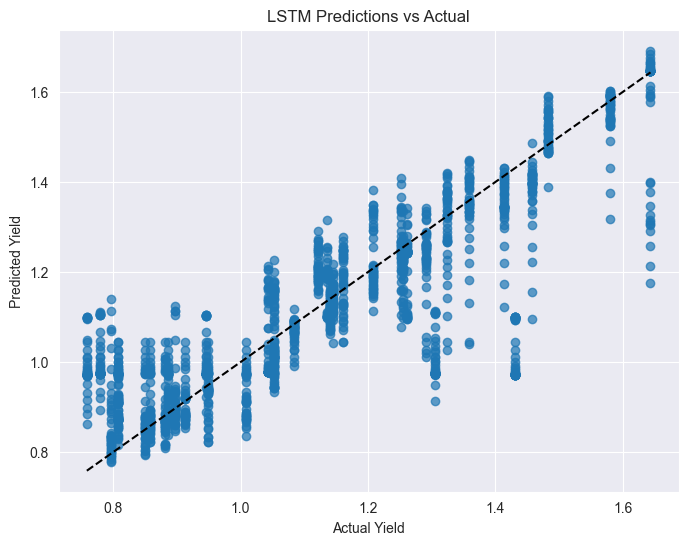

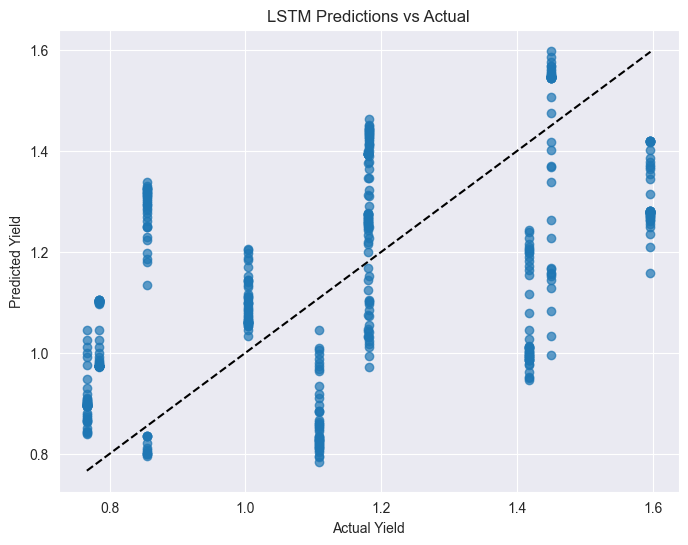

Train R²: 0.7115, Train MSE: 0.0166
Test R²: 0.2019, Test MSE: 0.0601


In [22]:
# from train_eval_functions import evaluate_model

state_dict = torch.load("best_model_hyper_param41.pth", map_location=device)
best_model.load_state_dict(state_dict)

# Training metrics
r2_train, mse_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, doInverseTransformScale = True,  plot_pred_vs_true=True)

print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}')


In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_1.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_1.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_1.save")